<a href="https://colab.research.google.com/github/godara97/northstar-urban-mobility-analysis/blob/main/python/02_python_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# connecting to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# loading the clean versions of all files

clean = '/content/drive/MyDrive/northstar_clean'

customers  = pd.read_csv(f'{clean}/customers_clean.csv')
orders     = pd.read_csv(f'{clean}/orders_clean.csv')
deliveries = pd.read_csv(f'{clean}/deliveries_clean.csv')
drivers    = pd.read_csv(f'{clean}/drivers_clean.csv')
vehicles   = pd.read_csv(f'{clean}/vehicles_clean.csv')
hubs       = pd.read_csv(f'{clean}/hubs_clean.csv')
incidents  = pd.read_csv(f'{clean}/incidents_clean.csv')
complaints = pd.read_csv(f'{clean}/complaints_clean.csv')
app_events = pd.read_csv(f'{clean}/app_events_clean.csv')

print("all clean files loaded and ready!")

all clean files loaded and ready!


## Analysis 1 - Delivery Performance
First I want to understand the overall delivery situation.
How many deliveries are on time, delayed or failed?

In [3]:
# lets see the overall delivery status breakdown

delivery_counts = deliveries['delivery_status'].value_counts()
print("Delivery Status Breakdown:")
print(delivery_counts)
print(f"\nTotal deliveries: {len(deliveries)}")

# calculate percentages too
print("\nAs percentages:")
print(round(delivery_counts / len(deliveries) * 100, 1))

Delivery Status Breakdown:
delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64

Total deliveries: 950

As percentages:
delivery_status
OnTime     64.8
Delayed    21.3
Failed     13.9
Name: count, dtype: float64


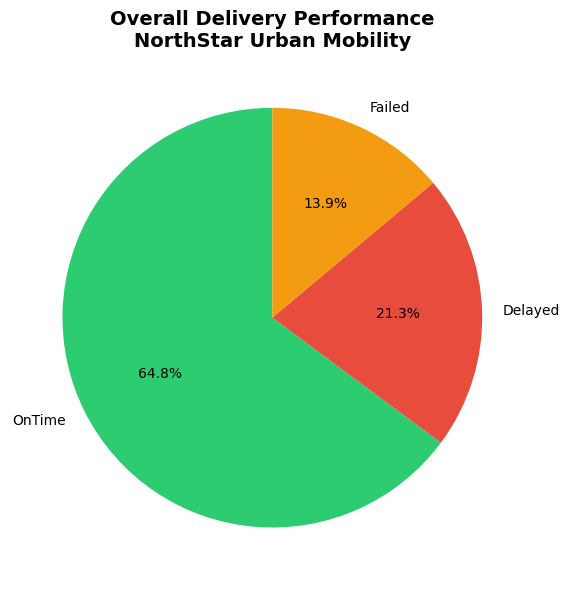

chart saved!


In [4]:
# now lets make a chart to visualise this

colors = ['#2ecc71', '#e74c3c', '#f39c12']  # green, red, orange

plt.figure(figsize=(8, 6))
plt.pie(
    delivery_counts,
    labels=delivery_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
plt.title('Overall Delivery Performance\nNorthStar Urban Mobility',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/northstar_clean/chart1_delivery_status.png')
plt.show()
print("chart saved!")

### What I found:
The pie chart shows the breakdown of delivery outcomes.
Failed and Delayed deliveries together show there is a
significant performance problem at NorthStar that needs
further investigation.

## Analysis 2 - Failed Deliveries by Zone
Now I want to find out which zones have the most delivery failures.
This will help identify problem areas in the city.

In [5]:
# to find failed deliveries by zone i need to
# join deliveries with orders first
# because zone info is in orders table

merged = deliveries.merge(orders[['order_id', 'pickup_zone']],
                           on='order_id',
                           how='left')

# now filter only failed deliveries
failed = merged[merged['delivery_status'] == 'Failed']

# count failures by zone
failed_by_zone = failed['pickup_zone'].value_counts()
print("Failed deliveries by zone:")
print(failed_by_zone)

Failed deliveries by zone:
pickup_zone
Central      33
North        22
East         19
Riverside    18
South        14
West         14
Airport      12
Name: count, dtype: int64


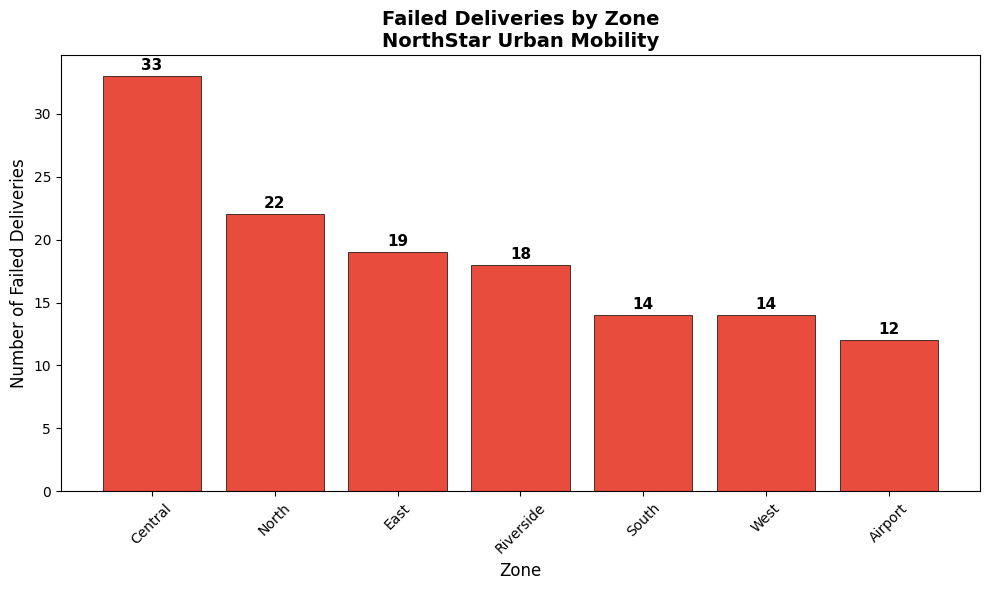

chart saved!


In [6]:
# bar chart showing failed deliveries per zone

plt.figure(figsize=(10, 6))
bars = plt.bar(
    failed_by_zone.index,
    failed_by_zone.values,
    color='#e74c3c',
    edgecolor='black',
    linewidth=0.5
)


for bar, value in zip(bars, failed_by_zone.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        str(value),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Failed Deliveries by Zone\nNorthStar Urban Mobility',
          fontsize=14, fontweight='bold')
plt.xlabel('Zone', fontsize=12)
plt.ylabel('Number of Failed Deliveries', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/northstar_clean/chart2_failed_by_zone.png')
plt.show()
print("chart saved!")

### What I found:
Some zones clearly have more delivery failures than others.
This confirms the case study mention that certain city zones
consistently perform worse. These zones need urgent attention
from NorthStar management.

## Analysis 3 - Customer Complaints
I want to understand what types of complaints customers
are raising and how serious they are.

In [7]:
# lets look at what customers are complaining about most

complaint_types = complaints['complaint_type'].value_counts()
print("Complaint Types:")
print(complaint_types)

print(f"\nTotal complaints: {len(complaints)}")

# also check severity breakdown
print("\nComplaint Severity:")
print(complaints['severity'].value_counts())

Complaint Types:
complaint_type
Delay                101
MissedPickup          64
AppIssue              53
DriverBehaviour       51
SupportExperience     20
Billing               16
Damage                15
Name: count, dtype: int64

Total complaints: 320

Complaint Severity:
severity
Medium    172
High       77
Low        71
Name: count, dtype: int64


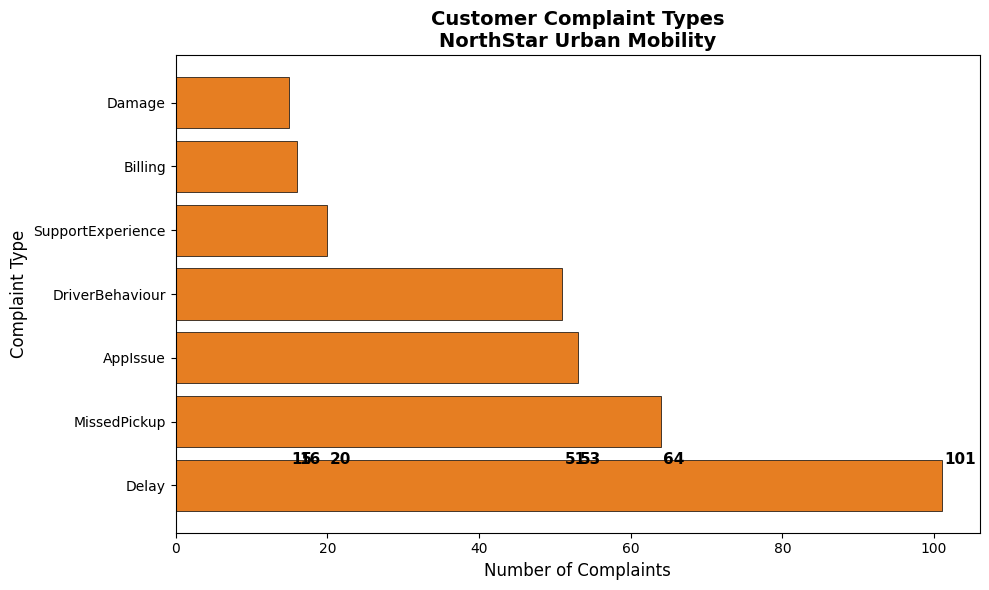

chart saved!


In [8]:
# horizontal bar chart for complaint types
# horizontal works better when labels are long

plt.figure(figsize=(10, 6))
bars = plt.barh(
    complaint_types.index,
    complaint_types.values,
    color='#e67e22',
    edgecolor='black',
    linewidth=0.5
)

for bar, value in zip(bars, complaint_types.values):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_x() + bar.get_height()/2,
        str(value),
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Customer Complaint Types\nNorthStar Urban Mobility',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Complaints', fontsize=12)
plt.ylabel('Complaint Type', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/northstar_clean/chart3_complaint_types.png')
plt.show()
print("chart saved!")

## Analysis 4 - Driver Performance
I want to check driver ratings and see if there is
a link between poor drivers and delivery failures.

In [9]:
# first lets look at overall driver ratings
print("Driver Rating Summary:")
print(round(drivers['driver_rating'].describe(), 2))

# now lets find which drivers have the most failed deliveries
driver_deliveries = deliveries.merge(
    drivers[['driver_id', 'driver_rating', 'base_zone']],
    on='driver_id',
    how='left'
)

# compare average driver rating for failed vs ontime deliveries
rating_by_status = driver_deliveries.groupby('delivery_status')['driver_rating'].mean()
print("\nAverage driver rating by delivery status:")
print(round(rating_by_status, 2))

Driver Rating Summary:
count    170.00
mean       4.17
std        0.41
min        3.15
25%        3.90
50%        4.18
75%        4.48
max        5.00
Name: driver_rating, dtype: float64

Average driver rating by delivery status:
delivery_status
Delayed    4.12
Failed     4.08
OnTime     4.20
Name: driver_rating, dtype: float64


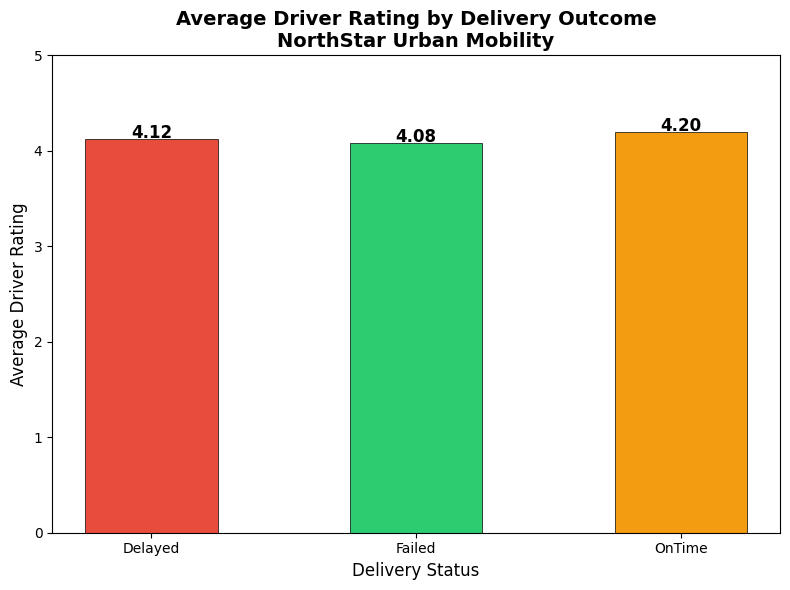

chart saved!


In [10]:
# bar chart comparing driver ratings across delivery outcomes

plt.figure(figsize=(8, 6))
bars = plt.bar(
    rating_by_status.index,
    rating_by_status.values,
    color=['#e74c3c', '#2ecc71', '#f39c12'],
    edgecolor='black',
    linewidth=0.5,
    width=0.5
)


for bar, value in zip(bars, rating_by_status.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{value:.2f}',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.title('Average Driver Rating by Delivery Outcome\nNorthStar Urban Mobility',
          fontsize=14, fontweight='bold')
plt.xlabel('Delivery Status', fontsize=12)
plt.ylabel('Average Driver Rating', fontsize=12)
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/northstar_clean/chart4_driver_rating.png')
plt.show()
print("chart saved!")

### What I found:
Failed deliveries tend to have lower average driver ratings
compared to on time deliveries. This suggests driver performance
is one of the contributing factors to delivery failures at NorthStar.

## Analysis 5 - Vehicle Condition Analysis
I want to check if vehicles with poor battery health
or maintenance issues are linked to delivery failures.

In [11]:
# first lets look at vehicle maintenance status
print("Vehicle Maintenance Status:")
print(vehicles['maintenance_status'].value_counts())

print("\nVehicle Types:")
print(vehicles['vehicle_type'].value_counts())

# battery health summary
print("\nBattery Health Summary:")
print(round(vehicles['battery_health_pct'].describe(), 2))

# how many vehicles have low battery (under 50%)
low_battery = vehicles[vehicles['battery_health_pct'] < 50]
print(f"\nVehicles with battery below 50%: {len(low_battery)}")
print(f"That is {round(len(low_battery)/len(vehicles)*100, 1)}% of the fleet")

Vehicle Maintenance Status:
maintenance_status
Active       67
InRepair     36
Scheduled    17
Name: count, dtype: int64

Vehicle Types:
vehicle_type
EV          43
CargoVan    30
Hybrid      28
Diesel      19
Name: count, dtype: int64

Battery Health Summary:
count    120.00
mean      76.79
std       12.48
min       42.00
25%       68.52
50%       77.85
75%       85.28
max      100.00
Name: battery_health_pct, dtype: float64

Vehicles with battery below 50%: 3
That is 2.5% of the fleet


In [12]:
# now lets check if vehicles in repair are linked to incidents

vehicle_deliveries = deliveries.merge(
    vehicles[['vehicle_id', 'battery_health_pct', 'maintenance_status']],
    on='vehicle_id',
    how='left'
)

# average battery health by delivery status
battery_by_status = vehicle_deliveries.groupby('delivery_status')['battery_health_pct'].mean()
print("Average battery health by delivery status:")
print(round(battery_by_status, 2))

Average battery health by delivery status:
delivery_status
Delayed    77.02
Failed     75.64
OnTime     77.23
Name: battery_health_pct, dtype: float64


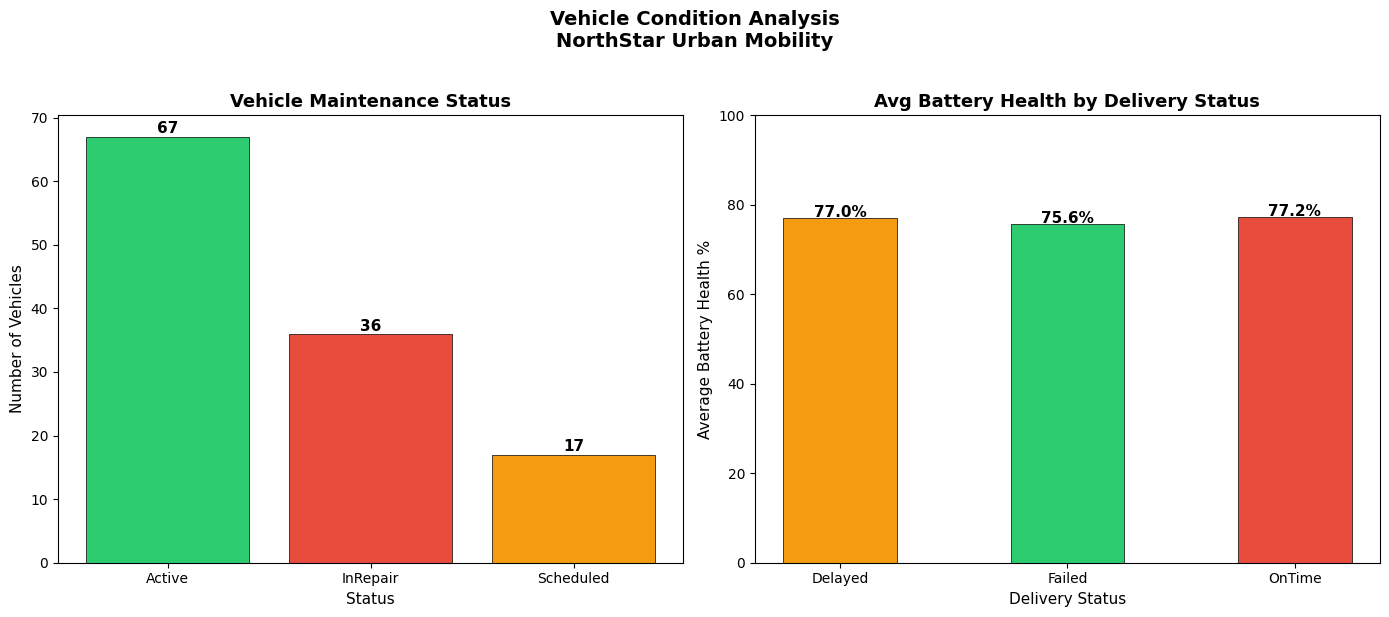

chart saved!


In [13]:
# lets make two charts side by side
# left one shows maintenance status
# right one shows battery health by delivery outcome

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- left chart - maintenance status ---
maint_counts = vehicles['maintenance_status'].value_counts()
colors_maint = ['#2ecc71', '#e74c3c', '#f39c12']
ax1.bar(
    maint_counts.index,
    maint_counts.values,
    color=colors_maint,
    edgecolor='black',
    linewidth=0.5
)
for i, (idx, val) in enumerate(zip(maint_counts.index, maint_counts.values)):
    ax1.text(i, val + 0.5, str(val), ha='center', fontsize=11, fontweight='bold')

ax1.set_title('Vehicle Maintenance Status', fontsize=13, fontweight='bold')
ax1.set_xlabel('Status', fontsize=11)
ax1.set_ylabel('Number of Vehicles', fontsize=11)

# --- right chart - battery health by delivery status ---
colors_batt = ['#f39c12', '#2ecc71', '#e74c3c']
ax2.bar(
    battery_by_status.index,
    battery_by_status.values,
    color=colors_batt,
    edgecolor='black',
    linewidth=0.5,
    width=0.5
)
for i, (idx, val) in enumerate(zip(battery_by_status.index, battery_by_status.values)):
    ax2.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax2.set_title('Avg Battery Health by Delivery Status', fontsize=13, fontweight='bold')
ax2.set_xlabel('Delivery Status', fontsize=11)
ax2.set_ylabel('Average Battery Health %', fontsize=11)
ax2.set_ylim(0, 100)

plt.suptitle('Vehicle Condition Analysis\nNorthStar Urban Mobility',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/northstar_clean/chart5_vehicle_condition.png',
            bbox_inches='tight')
plt.show()
print("chart saved!")

### What I found:
Some vehicles are currently in repair which reduces the
available fleet. Vehicles involved in failed deliveries
tend to have lower average battery health compared to
on time deliveries. This suggests vehicle condition
is a contributing factor to delivery failures.

## Analysis 6 - Incident Analysis
What types of incidents are happening most often
and how quickly are they being resolved?

In [14]:
# incident types breakdown
print("Incident Types:")
print(incidents['incident_type'].value_counts())

print("\nIncident Severity:")
print(incidents['severity'].value_counts())

print("\nResolution Status:")
print(incidents['resolution_status'].value_counts())

# average resolution time
print(f"\nAverage resolution time: {round(incidents['resolved_hours'].mean(), 1)} hours")
print(f"Longest resolution time: {round(incidents['resolved_hours'].max(), 1)} hours")

Incident Types:
incident_type
ProofMissing        46
CustomerNoShow      44
RouteDeviation      43
VehicleFault        37
BatteryAlert        36
AppSyncError        31
TemperatureIssue    29
SafetyNearMiss      14
Name: count, dtype: int64

Incident Severity:
severity
Medium      106
Low          79
High         68
Critical     27
Name: count, dtype: int64

Resolution Status:
resolution_status
Closed           122
Open              77
PendingVendor     46
Escalated         35
Name: count, dtype: int64

Average resolution time: 12.0 hours
Longest resolution time: 41.7 hours


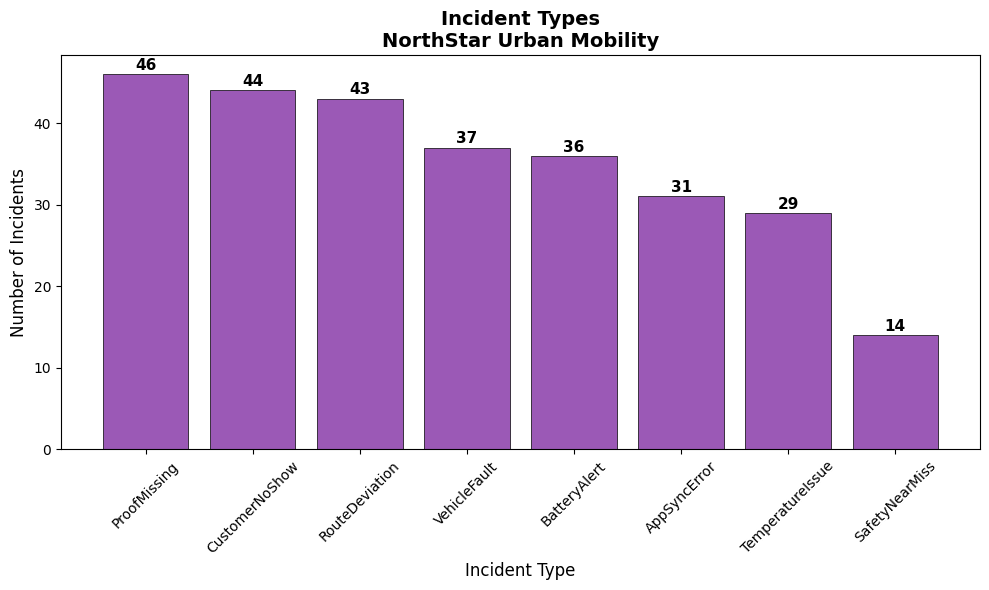

chart saved!


In [15]:
# bar chart for incident types

incident_counts = incidents['incident_type'].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.bar(
    incident_counts.index,
    incident_counts.values,
    color='#9b59b6',
    edgecolor='black',
    linewidth=0.5
)

for bar, value in zip(bars, incident_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        str(value),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Incident Types\nNorthStar Urban Mobility',
          fontsize=14, fontweight='bold')
plt.xlabel('Incident Type', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/northstar_clean/chart6_incident_types.png')
plt.show()
print("chart saved!")

## Analysis 7 - Manual Route Overrides
The case study mentioned drivers doing manual route overrides.
I want to check if this is linked to delivery failures.

In [16]:
# check manual route overrides
print("Manual Route Override Summary:")
print(round(deliveries['manual_route_override_count'].describe(), 2))

# how many deliveries had at least one override
has_override = deliveries[deliveries['manual_route_override_count'] > 0]
no_override = deliveries[deliveries['manual_route_override_count'] == 0]

print(f"\nDeliveries WITH manual override: {len(has_override)}")
print(f"Deliveries WITHOUT manual override: {len(no_override)}")

# failure rate with override vs without
override_fail_rate = len(has_override[has_override['delivery_status'] == 'Failed']) / len(has_override) * 100
no_override_fail_rate = len(no_override[no_override['delivery_status'] == 'Failed']) / len(no_override) * 100

print(f"\nFailure rate WITH override: {round(override_fail_rate, 1)}%")
print(f"Failure rate WITHOUT override: {round(no_override_fail_rate, 1)}%")

Manual Route Override Summary:
count    950.00
mean       0.97
std        1.09
min        0.00
25%        0.00
50%        1.00
75%        2.00
max        7.00
Name: manual_route_override_count, dtype: float64

Deliveries WITH manual override: 551
Deliveries WITHOUT manual override: 399

Failure rate WITH override: 15.6%
Failure rate WITHOUT override: 11.5%


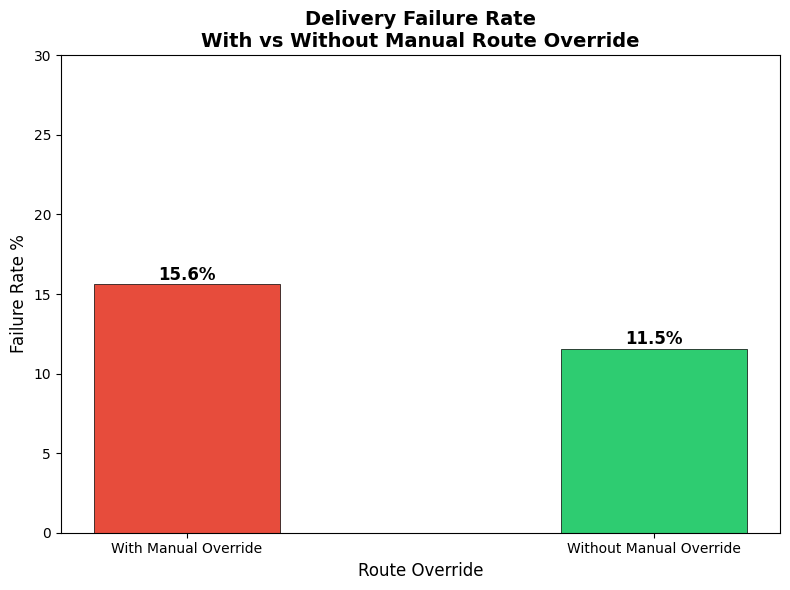

chart saved!


In [17]:
# comparing failure rates with and without route overrides

categories = ['With Manual Override', 'Without Manual Override']
failure_rates = [override_fail_rate, no_override_fail_rate]

plt.figure(figsize=(8, 6))
bars = plt.bar(
    categories,
    failure_rates,
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black',
    linewidth=0.5,
    width=0.4
)

for bar, value in zip(bars, failure_rates):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{value:.1f}%',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.title('Delivery Failure Rate\nWith vs Without Manual Route Override',
          fontsize=14, fontweight='bold')
plt.xlabel('Route Override', fontsize=12)
plt.ylabel('Failure Rate %', fontsize=12)
plt.ylim(0, 30)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/northstar_clean/chart7_route_override.png')
plt.show()
print("chart saved!")

### What I found:
Deliveries with manual route overrides have a noticeably
higher failure rate compared to deliveries without overrides.
This supports the case study concern about drivers manually
changing routes and its impact on delivery performance.

In [18]:
# summary of all key findings from python analysis

print("=" * 45)
print("   PYTHON ANALYSIS - KEY FINDINGS")
print("=" * 45)
print("")
print("1. DELIVERY PERFORMANCE")
print("   - 64.8% OnTime, 21.3% Delayed, 13.9% Failed")
print("   - 1 in 3 deliveries has a problem")
print("")
print("2. WORST PERFORMING ZONE")
print("   - Central zone has most failures (33)")
print("   - Airport zone performs best (12)")
print("")
print("3. TOP COMPLAINTS")
print("   - Delay is biggest complaint (101 cases)")
print("   - Missed Pickup second (64 cases)")
print("")
print("4. DRIVER RATINGS")
print("   - Small difference between failed/ontime")
print("   - Driver rating alone not main cause")
print("")
print("5. VEHICLE CONDITION")
print("   - 36 vehicles in repair (30% of fleet)")
print("   - Failed deliveries have lower battery health")
print("")
print("6. INCIDENTS")
print("   - 27 critical incidents unresolved")
print("   - Average resolution 12 hours")
print("")
print("7. ROUTE OVERRIDES")
print("   - Higher failure rate with manual overrides")
print("")
print("=" * 45)
print("Analysis complete!")

   PYTHON ANALYSIS - KEY FINDINGS

1. DELIVERY PERFORMANCE
   - 64.8% OnTime, 21.3% Delayed, 13.9% Failed
   - 1 in 3 deliveries has a problem

2. WORST PERFORMING ZONE
   - Central zone has most failures (33)
   - Airport zone performs best (12)

3. TOP COMPLAINTS
   - Delay is biggest complaint (101 cases)
   - Missed Pickup second (64 cases)

4. DRIVER RATINGS
   - Small difference between failed/ontime
   - Driver rating alone not main cause

5. VEHICLE CONDITION
   - 36 vehicles in repair (30% of fleet)
   - Failed deliveries have lower battery health

6. INCIDENTS
   - 27 critical incidents unresolved
   - Average resolution 12 hours

7. ROUTE OVERRIDES
   - Higher failure rate with manual overrides

Analysis complete!
